# Giảm FP LightGBM v2.1 — ngưỡng / dual-score / segment

**Mục tiêu:** giảm False Positive so v2.1 @ 0,28, **giữ Recall Hủy ≥ 0,85**.  
**Phạm vi:** không retrain Optuna / không thêm feature — chỉ đổi luật quyết định trên `P(hủy)` từ **v2** và **v2.1**.

| Luật | Định nghĩa |
|------|------------|
| **A — Global** | `p_v21 ≥ t` (quét 0,28→0,55, bước 0,01) |
| **B — Dual AND** | `p_v21 ≥ t21` và `p_v2 ≥ t2` |
| **C — Segment** | ngưỡng riêng Online TA vs còn lại |

**Chọn winner:** min FP → max Precision → max Recall (trong ràng buộc Recall ≥ 0,85).

Script tương đương: `_run_10_fp_reduction.py` · Artifact: `artifacts/fp_reduction_policy_v2_1.json`


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Resolve project root whether cwd is repo root or this model folder
_cwd = Path.cwd().resolve()
if (_cwd / "data" / "hotel_bookings_v5.csv").exists():
    ROOT = _cwd
elif (_cwd.parents[1] / "data" / "hotel_bookings_v5.csv").exists():
    ROOT = _cwd.parents[1]
elif (_cwd / "hotel_bookings_v5.csv").exists() is False and (
    _cwd.parent.parent / "data" / "hotel_bookings_v5.csv"
).exists():
    ROOT = _cwd.parent.parent
else:
    ROOT = _cwd.parents[1]

MODEL_DIR = ROOT / "models" / "Cancellation Predict Model v2"
CSV_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
ARTIFACT_DIR = MODEL_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
POLICY_PATH = ARTIFACT_DIR / "fp_reduction_policy_v2_1.json"
V21_PARAMS_PATH = ARTIFACT_DIR / "best_params_v2_1.json"
FIG_DIR = ROOT / "reports" / "figures" / "09_fp"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
MIN_RECALL = 0.85

print("ROOT:", ROOT)
print("CSV exists:", CSV_PATH.exists())
print("v2.1 params:", V21_PARAMS_PATH.exists())


ROOT: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
CSV exists: True
v2.1 params: True


## 1. Feature engineering & params (đồng bộ v2 / v2.1)


In [2]:
MONTH_TO_NUM = {
    m: i + 1
    for i, m in enumerate([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ])
}

CAT_V2 = [
    "deposit_type", "market_segment", "country", "distribution_channel",
    "customer_type", "hotel",
]
CAT_V21 = CAT_V2 + ["arrival_season"]
NUM = [
    "lead_time", "total_of_special_requests", "total_guests", "price_per_person",
    "is_family", "total_nights", "lead_time_per_night", "history_cancel_rate",
    "is_weekend_only", "arrival_month_mapped",
]
TARGET = "is_canceled"

V2_PARAMS = {
    "n_estimators": 250,
    "max_depth": 15,
    "num_leaves": 61,
    "min_child_samples": 35,
    "learning_rate": 0.06327088846969782,
    "subsample": 0.7957118696489107,
    "colsample_bytree": 0.6332771647068834,
    "reg_alpha": 0.008189179973637264,
    "reg_lambda": 3.265450956311304,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}


def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    out = raw.copy()
    out["children"] = out["children"].fillna(0)
    out["total_guests"] = (out["adults"] + out["children"] + out["babies"]).clip(lower=1)
    out["price_per_person"] = out["adr"] / out["total_guests"]
    out["is_family"] = ((out["children"] > 0) | (out["babies"] > 0)).astype(int)
    out["total_nights"] = out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    out["lead_time_per_night"] = out["lead_time"] / out["total_nights"].clip(lower=1)
    prior = out["previous_cancellations"] + out["previous_bookings_not_canceled"]
    out["history_cancel_rate"] = np.where(prior > 0, out["previous_cancellations"] / prior, 0.0)
    out["is_weekend_only"] = (
        (out["stays_in_weekend_nights"] > 0) & (out["stays_in_week_nights"] == 0)
    ).astype(int)
    out["arrival_month_mapped"] = out["arrival_date_month"].map(MONTH_TO_NUM).fillna(0).astype(int)
    month = out["arrival_month_mapped"]
    out["arrival_season"] = np.select(
        [month.isin([12, 1, 2]), month.isin([3, 4, 5]), month.isin([6, 7, 8]), month.isin([9, 10, 11])],
        ["Winter", "Spring", "Summer", "Autumn"],
        default="Unknown",
    )
    return out


def prepare(df: pd.DataFrame, cat_cols: list[str]) -> pd.DataFrame:
    cols = cat_cols + NUM + [TARGET]
    model_df = engineer_features(df)[cols].copy()
    model_df["country"] = model_df["country"].fillna("Unknown").astype(str)
    for col in cat_cols:
        model_df[col] = model_df[col].astype(str)
    for col in ["lead_time", "total_of_special_requests", "total_guests", "is_family",
                "total_nights", "is_weekend_only", "arrival_month_mapped"]:
        model_df[col] = model_df[col].fillna(0).astype(int)
    for col in ["price_per_person", "lead_time_per_night", "history_cancel_rate"]:
        model_df[col] = model_df[col].fillna(0.0).astype(float)
    return model_df


def make_pipeline(cat_cols: list[str], params: dict) -> Pipeline:
    enc = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False)
    pre = ColumnTransformer(
        [("cat", enc, cat_cols), ("num", "passthrough", NUM)],
        remainder="drop",
    )
    return Pipeline([("preprocessor", pre), ("classifier", LGBMClassifier(**params))])


def metrics_from_pred(y_true, y_hat, y_proba=None) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    out = {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "precision_cancel": float(precision_score(y_true, y_hat, pos_label=1, zero_division=0)),
        "recall_cancel": float(recall_score(y_true, y_hat, pos_label=1, zero_division=0)),
        "f1_cancel": float(f1_score(y_true, y_hat, pos_label=1, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
    }
    if y_proba is not None:
        out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    return out


def pick_winner(candidates: list[dict]) -> dict | None:
    feasible = [c for c in candidates if c["metrics"]["recall_cancel"] >= MIN_RECALL]
    if not feasible:
        return None
    return min(
        feasible,
        key=lambda c: (c["metrics"]["fp"], -c["metrics"]["precision_cancel"], -c["metrics"]["recall_cancel"]),
    )

print("Helpers ready.")


Helpers ready.


## 2. Load data, fit v2 + v2.1, lấy xác suất test


In [3]:
read_cols = list(dict.fromkeys(
    CAT_V2 + [
        "lead_time", "total_of_special_requests", "adults", "children", "babies", "adr",
        "stays_in_weekend_nights", "stays_in_week_nights", "previous_bookings_not_canceled",
        "arrival_date_month", "previous_cancellations", TARGET,
    ]
))
raw = pd.read_csv(CSV_PATH, usecols=read_cols)

df_v2 = prepare(raw, CAT_V2)
df_v21 = prepare(raw, CAT_V21)
X_v2 = df_v2[CAT_V2 + NUM]
X_v21 = df_v21[CAT_V21 + NUM]
y = df_v2[TARGET].astype(int)

X2_train, X2_test, y_train, y_test = train_test_split(
    X_v2, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X21_train, X21_test, _, _ = train_test_split(
    X_v21, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

v21_artifact = json.loads(V21_PARAMS_PATH.read_text(encoding="utf-8"))
v21_params = {**v21_artifact["params"], "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1}

pipe_v2 = make_pipeline(CAT_V2, V2_PARAMS)
pipe_v21 = make_pipeline(CAT_V21, v21_params)
pipe_v2.fit(X2_train, y_train)
pipe_v21.fit(X21_train, y_train)

p_v2 = pipe_v2.predict_proba(X2_test)[:, 1]
p_v21 = pipe_v21.predict_proba(X21_test)[:, 1]
is_online = (X21_test["market_segment"].astype(str) == "Online TA").to_numpy()

baseline_v21 = metrics_from_pred(y_test, (p_v21 >= 0.28).astype(int), p_v21)
baseline_v2 = metrics_from_pred(y_test, (p_v2 >= 0.35).astype(int), p_v2)

print("Test size:", len(y_test))
print("Baseline v2.1 @ 0.28:", baseline_v21)
print("Baseline v2   @ 0.35:", baseline_v2)


Test size: 16563
Baseline v2.1 @ 0.28: {'tn': 5930, 'fp': 5976, 'fn': 225, 'tp': 4432, 'precision_cancel': 0.425826287471176, 'recall_cancel': 0.9516856345286665, 'f1_cancel': 0.5883836707600398, 'accuracy': 0.6256113023003079, 'roc_auc': 0.8719555961971237}
Baseline v2   @ 0.35: {'tn': 7576, 'fp': 4330, 'fn': 469, 'tp': 4188, 'precision_cancel': 0.4916647100258277, 'recall_cancel': 0.8992913893064205, 'f1_cancel': 0.6357495256166983, 'accuracy': 0.7102578035380064, 'roc_auc': 0.871152052108419}


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. Quét luật A / B / C và chọn winner


In [4]:
def sweep_global(p_v21, y_test):
    rows = []
    for t in np.round(np.arange(0.28, 0.56, 0.01), 2):
        y_hat = (p_v21 >= t).astype(int)
        rows.append({
            "rule_type": "global",
            "policy_name": f"global_t={t:.2f}",
            "thresholds": {"t": float(t)},
            "metrics": metrics_from_pred(y_test, y_hat, p_v21),
        })
    return rows


def sweep_dual(p_v21, p_v2, y_test):
    rows = []
    grid = np.round(np.arange(0.28, 0.56, 0.02), 2)
    for t21 in grid:
        for t2 in grid:
            y_hat = ((p_v21 >= t21) & (p_v2 >= t2)).astype(int)
            rows.append({
                "rule_type": "dual_and",
                "policy_name": f"dual_t21={t21:.2f}_t2={t2:.2f}",
                "thresholds": {"t21": float(t21), "t2": float(t2)},
                "metrics": metrics_from_pred(y_test, y_hat, p_v21),
            })
    return rows


def sweep_segment(p_v21, y_test, is_online):
    rows = []
    grid = np.round(np.arange(0.28, 0.56, 0.02), 2)
    for t_online in grid:
        for t_other in grid:
            thr = np.where(is_online, t_online, t_other)
            y_hat = (p_v21 >= thr).astype(int)
            rows.append({
                "rule_type": "segment",
                "policy_name": f"segment_online={t_online:.2f}_other={t_other:.2f}",
                "thresholds": {"t_online_ta": float(t_online), "t_other": float(t_other)},
                "metrics": metrics_from_pred(y_test, y_hat, p_v21),
            })
    return rows

cand_a = sweep_global(p_v21, y_test)
cand_b = sweep_dual(p_v21, p_v2, y_test)
cand_c = sweep_segment(p_v21, y_test, is_online)

best_a = pick_winner(cand_a)
best_b = pick_winner(cand_b)
best_c = pick_winner(cand_c)
winner = pick_winner([b for b in (best_a, best_b, best_c) if b is not None])

def _row(label, best):
    if best is None:
        return {"name": label, "fp": None, "fn": None, "recall_cancel": None, "precision_cancel": None}
    return {
        "name": f"{label}: {best['policy_name']}",
        "fp": best["metrics"]["fp"],
        "fn": best["metrics"]["fn"],
        "recall_cancel": best["metrics"]["recall_cancel"],
        "precision_cancel": best["metrics"]["precision_cancel"],
        "f1_cancel": best["metrics"]["f1_cancel"],
    }

cmp = pd.DataFrame([
    {"name": "v2.1 @ 0.28", **{k: baseline_v21[k] for k in ["fp", "fn", "recall_cancel", "precision_cancel", "f1_cancel"]}},
    {"name": "v2 @ 0.35", **{k: baseline_v2[k] for k in ["fp", "fn", "recall_cancel", "precision_cancel", "f1_cancel"]}},
    _row("A best", best_a),
    _row("B best", best_b),
    _row("C best", best_c),
    _row("WINNER", winner),
])
display(cmp)
print("WINNER:", winner["policy_name"] if winner else None)


,name,fp,fn,recall_cancel,precision_cancel,f1_cancel
0,v2.1 @ 0.28,5976,225,0.951686,0.425826,0.588384
1,v2 @ 0.35,4330,469,0.899291,0.491665,0.635750
2,A best: global_t=0.51,3312,684,0.853124,0.545367,0.665383
3,B best: dual_t21=0.50_t2=0.38,3338,687,0.852480,0.543240,0.663602
4,C best: segment_online=0.52_other=0.48,3326,687,0.852480,0.544134,0.664268
5,WINNER: global_t=0.51,3312,684,0.853124,0.545367,0.665383


WINNER: global_t=0.51


## 4. Biểu đồ & lưu artifact


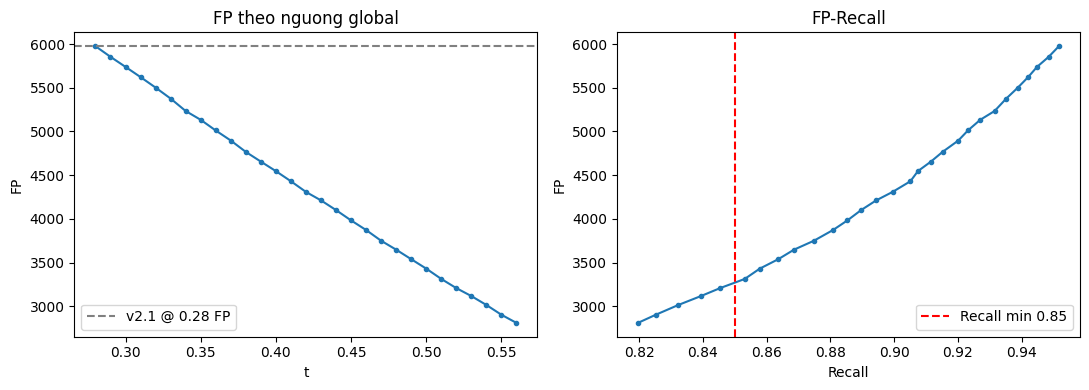

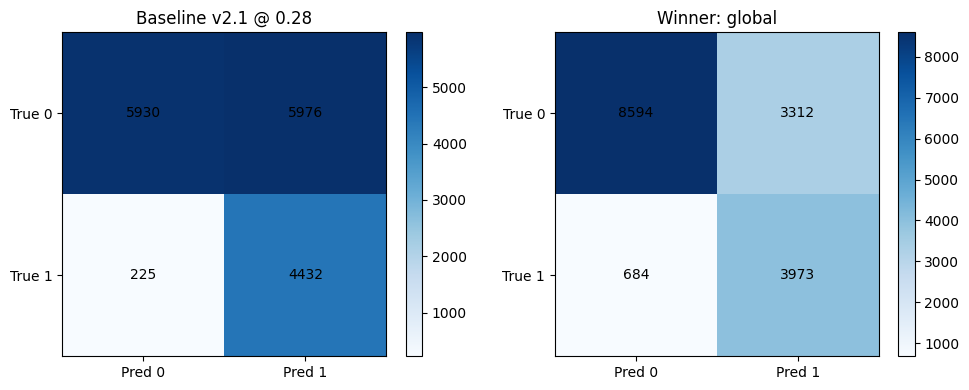

Saved: fp_reduction_policy_v2_1.json


In [5]:
curve = pd.DataFrame([
    {"t": c["thresholds"]["t"], "fp": c["metrics"]["fp"], "recall": c["metrics"]["recall_cancel"]}
    for c in cand_a
])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(curve["t"], curve["fp"], marker="o", ms=3)
ax[0].axhline(baseline_v21["fp"], color="gray", ls="--", label="v2.1 @ 0.28 FP")
ax[0].set_xlabel("t"); ax[0].set_ylabel("FP"); ax[0].set_title("FP theo nguong global"); ax[0].legend()
ax[1].plot(curve["recall"], curve["fp"], marker="o", ms=3)
ax[1].axvline(MIN_RECALL, color="red", ls="--", label="Recall min 0.85")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("FP"); ax[1].set_title("FP-Recall"); ax[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "chart_01_fp_recall_curve.png", dpi=120, bbox_inches="tight")
plt.show()

if winner["rule_type"] == "global":
    y_win = (p_v21 >= winner["thresholds"]["t"]).astype(int)
elif winner["rule_type"] == "dual_and":
    y_win = ((p_v21 >= winner["thresholds"]["t21"]) & (p_v2 >= winner["thresholds"]["t2"])).astype(int)
else:
    thr = np.where(is_online, winner["thresholds"]["t_online_ta"], winner["thresholds"]["t_other"])
    y_win = (p_v21 >= thr).astype(int)

y_base = (p_v21 >= 0.28).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_hat, title in [(axes[0], y_base, "Baseline v2.1 @ 0.28"), (axes[1], y_win, f"Winner: {winner['rule_type']}")]:
    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG_DIR / "chart_02_confusion_baseline_vs_winner.png", dpi=120, bbox_inches="tight")
plt.show()

summary = {
    "policy_name": winner["policy_name"],
    "rule_type": winner["rule_type"],
    "thresholds": winner["thresholds"],
    "constraint": {"min_recall_cancel": MIN_RECALL},
    "test_metrics": winner["metrics"],
    "baselines": {"v2_1_at_0_28": baseline_v21, "v2_at_0_35": baseline_v2},
    "best_per_rule": {
        "global": None if best_a is None else {"policy_name": best_a["policy_name"], "thresholds": best_a["thresholds"], "metrics": best_a["metrics"]},
        "dual_and": None if best_b is None else {"policy_name": best_b["policy_name"], "thresholds": best_b["thresholds"], "metrics": best_b["metrics"]},
        "segment": None if best_c is None else {"policy_name": best_c["policy_name"], "thresholds": best_c["thresholds"], "metrics": best_c["metrics"]},
    },
    "selection_order": ["min_fp", "max_precision_cancel", "max_recall_cancel"],
    "n_test": int(len(y_test)),
    "data": "hotel_bookings_v5.csv",
    "split": {"test_size": TEST_SIZE, "random_state": RANDOM_STATE, "stratify": True},
}
POLICY_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
cmp.to_csv(ARTIFACT_DIR / "fp_reduction_comparison.csv", index=False)
print("Saved:", POLICY_PATH.name)


## 5. Kết luận vận hành

- **Mode inventory (Recall max):** giữ v2.1 @ **0,28**.
- **Mode giảm FP (Recall ≥ 0,85):** dùng policy trong `fp_reduction_policy_v2_1.json` (winner sau quét A/B/C).
- Chi tiết: `reports/09_fp_reduction_v2_1.md`.
